# Image Comparison
This is a simple notebook to plot and check the results of various detectors side by side. 
It loads the original image and the output from each detector, and combines them into a single
image for easy comparison.

## 1. Setup and Configuration

In [6]:
import os
os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'

import warnings
from pathlib import Path
import cv2
from matplotlib import pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)

workspace = Path.cwd()
results_dir = workspace / "results"
images_dir = workspace / "images"

## 2. Find Detectors and Their Output Images

### 2.2. Detectors
Find all subdirectories in the results directory that contain an "images" folder. These are our detector output folders.

In [7]:
detectors = []
folders = os.listdir(results_dir)

for folder in folders:
    path = results_dir / folder
    images_subdir = path / "images"
    
    if os.path.isdir(str(path)) and os.path.isdir(str(images_subdir)):
        detectors.append(folder)

detectors.sort()
print(f"Found detectors: {', '.join(detectors)}\n")

Found detectors: canny, sobel



## 2.2. Detector Output Images
For each detector, list all PNG images in its "images" subdirectory.

In [12]:
detector_image_map: dict[str, list[str]] = {}

for detector in detectors:
    detector_images_dir = results_dir / detector / "images"
    detector_files: list[str] = []
    detector_entries: list[str] = os.listdir(str(detector_images_dir))
    
    for filename in detector_entries:
        is_png: bool = filename.endswith('.png')
        if is_png:
            detector_files.append(filename)
    
    detector_image_map[detector] = detector_files
    print(f"  {detector}: {len(detector_files)} images")

  canny: 5 images
  sobel: 10 images


## 3. Find Common Images Across All Detectors
We want to find the set of images that are present in the output of all detectors.
This is done by checking each image in the smallest detector list for membership in 
the others.

<!-- 
FIND INTERSECTION: Images present in ALL detectors
Algorithm: O(n*m) - for each original, check membership in m detector lists

An Optimisation:
  Since we know that the maximum amount of images in the intersection is 
  bounded by the smallest detector list, we can just loop over that list and
  check membership in the others. 
-->

In [13]:
common: list[str] = []
og_images: list[str] = []

# Get the detector list with minimum images to optimize intersection
min_detector: str = min(detectors, key=lambda d: len(detector_image_map[d]))

for image in detector_image_map[min_detector]:
    is_in_all_detectors: bool = True
    
    for detector in detectors:
        if image not in detector_image_map[detector]:
            is_in_all_detectors = False
            break
    
    if is_in_all_detectors:
        # Also add it to the list of original images for later loading
        og_images.append(image)
        common.append(image)

common.sort()
print(f"Common (all detectors): {len(common)} images\n")

Common (all detectors): 5 images



## 4. Combine and Show images
For each common image, load the original and the detector outputs, and combine them into a single plot for
easy comparison.

Combining 5 images...


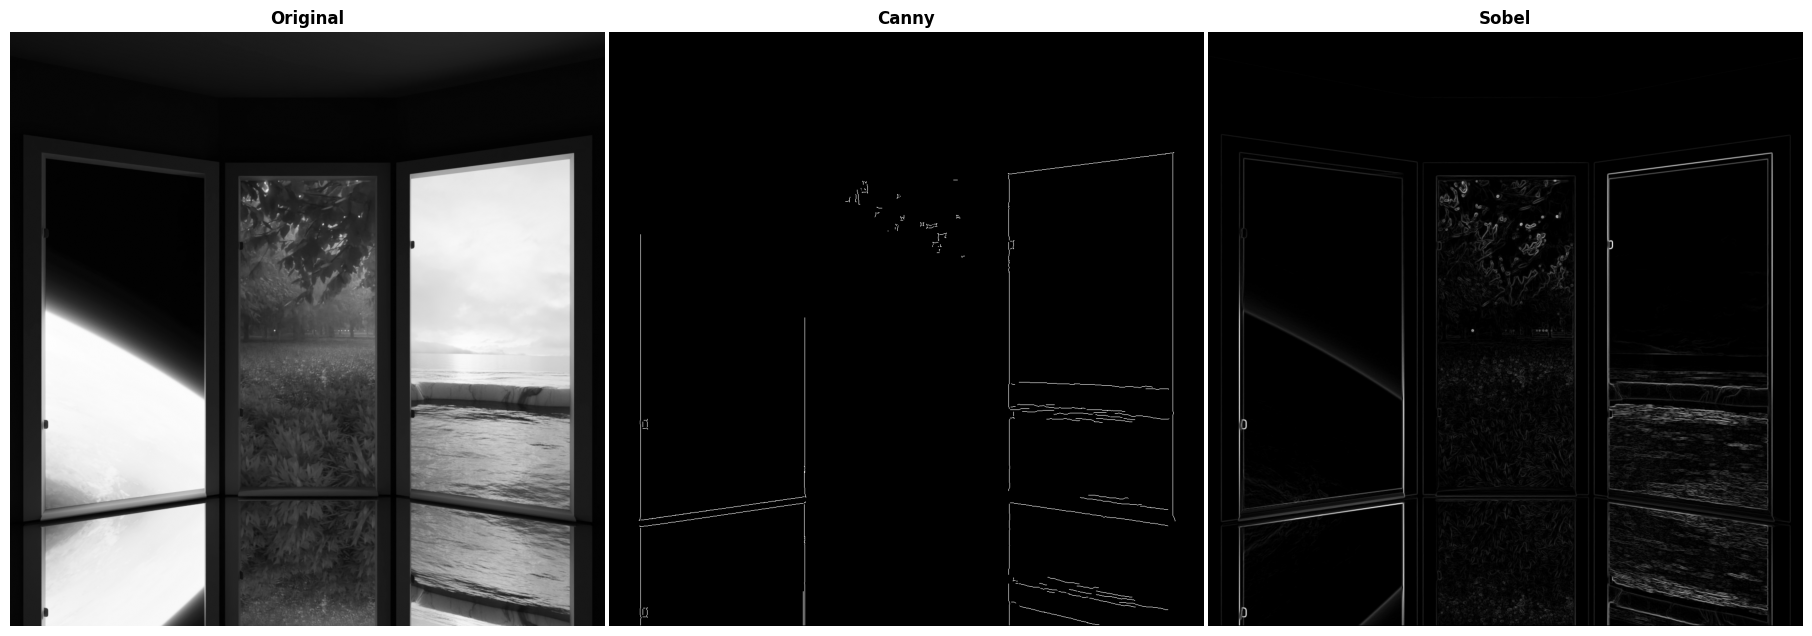

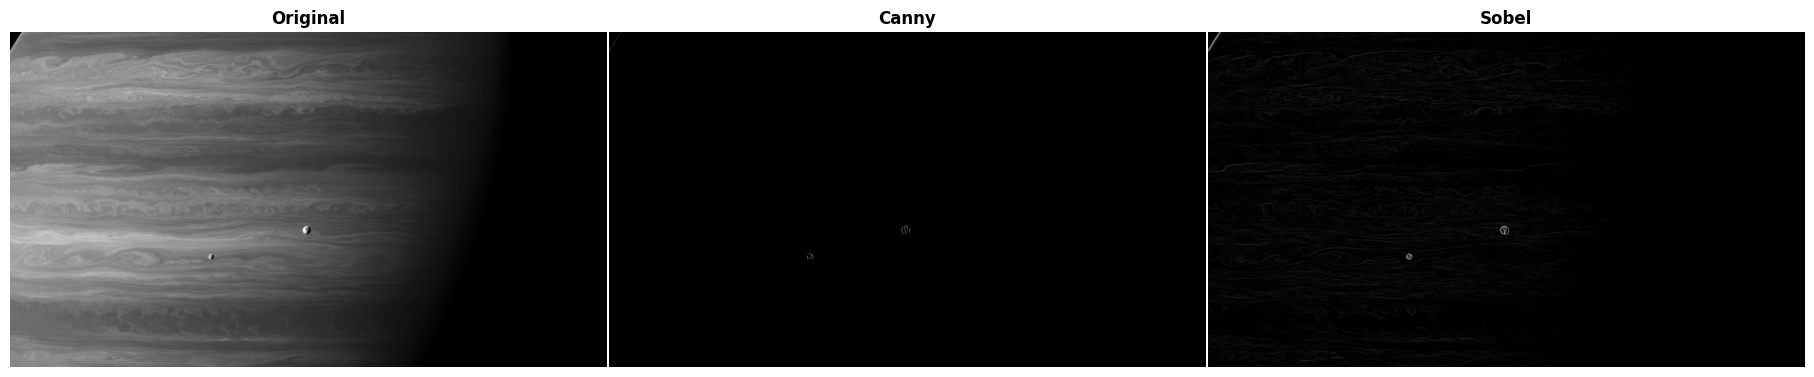

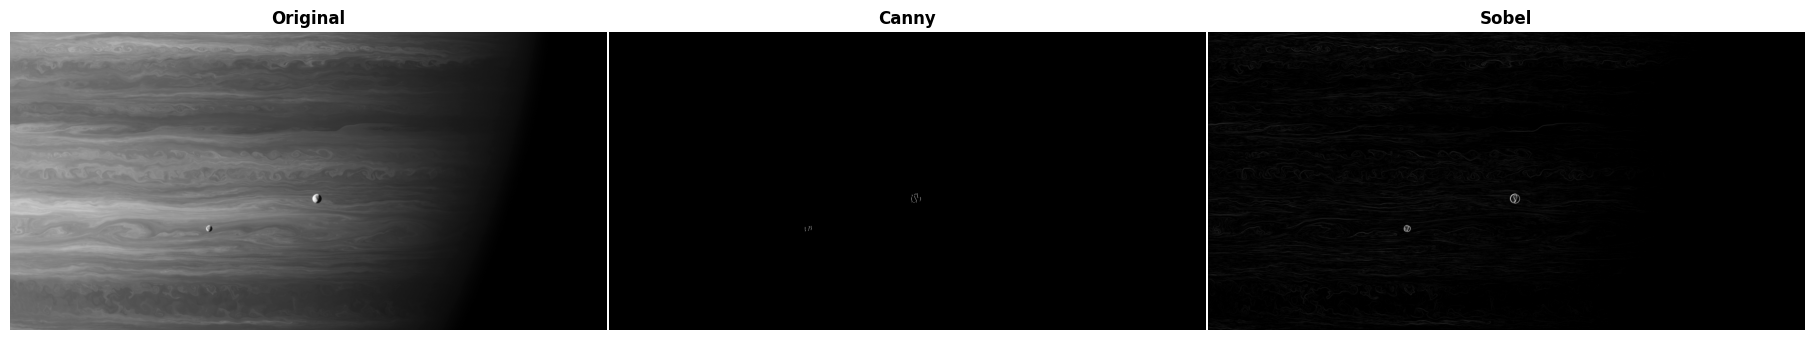

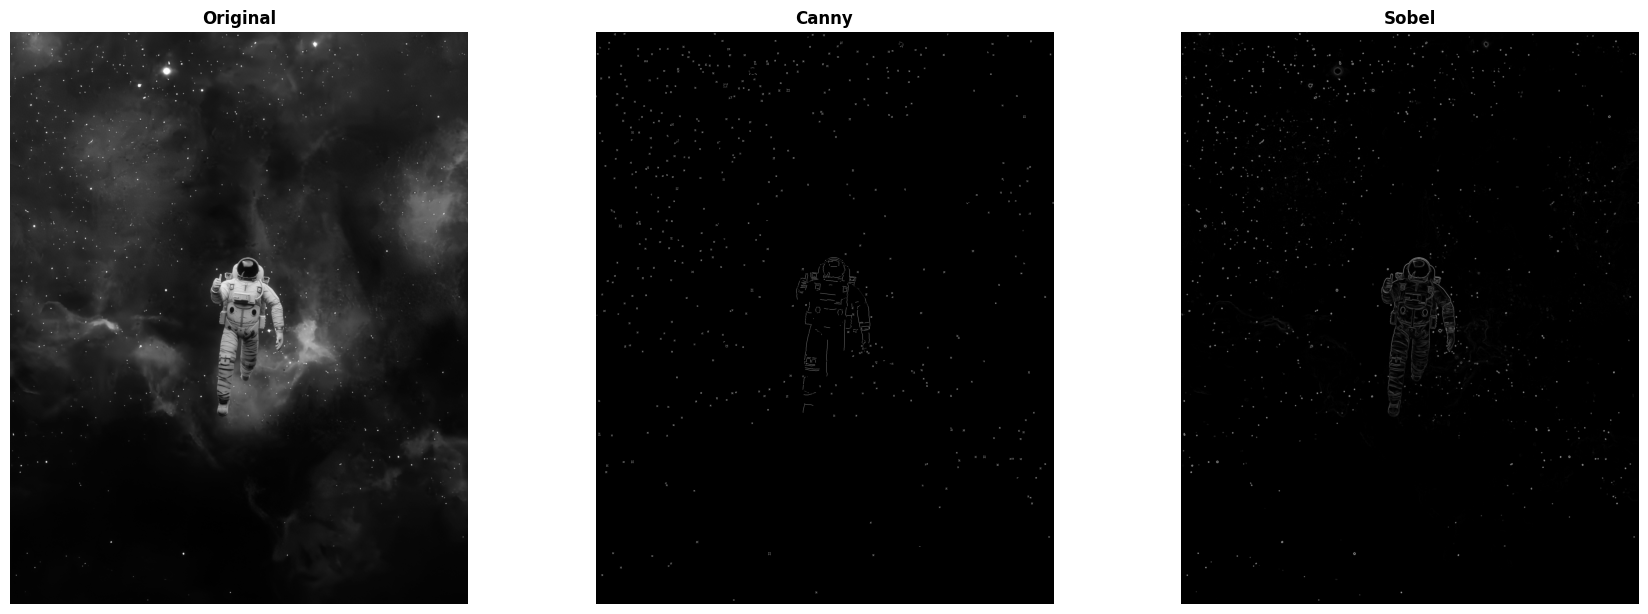

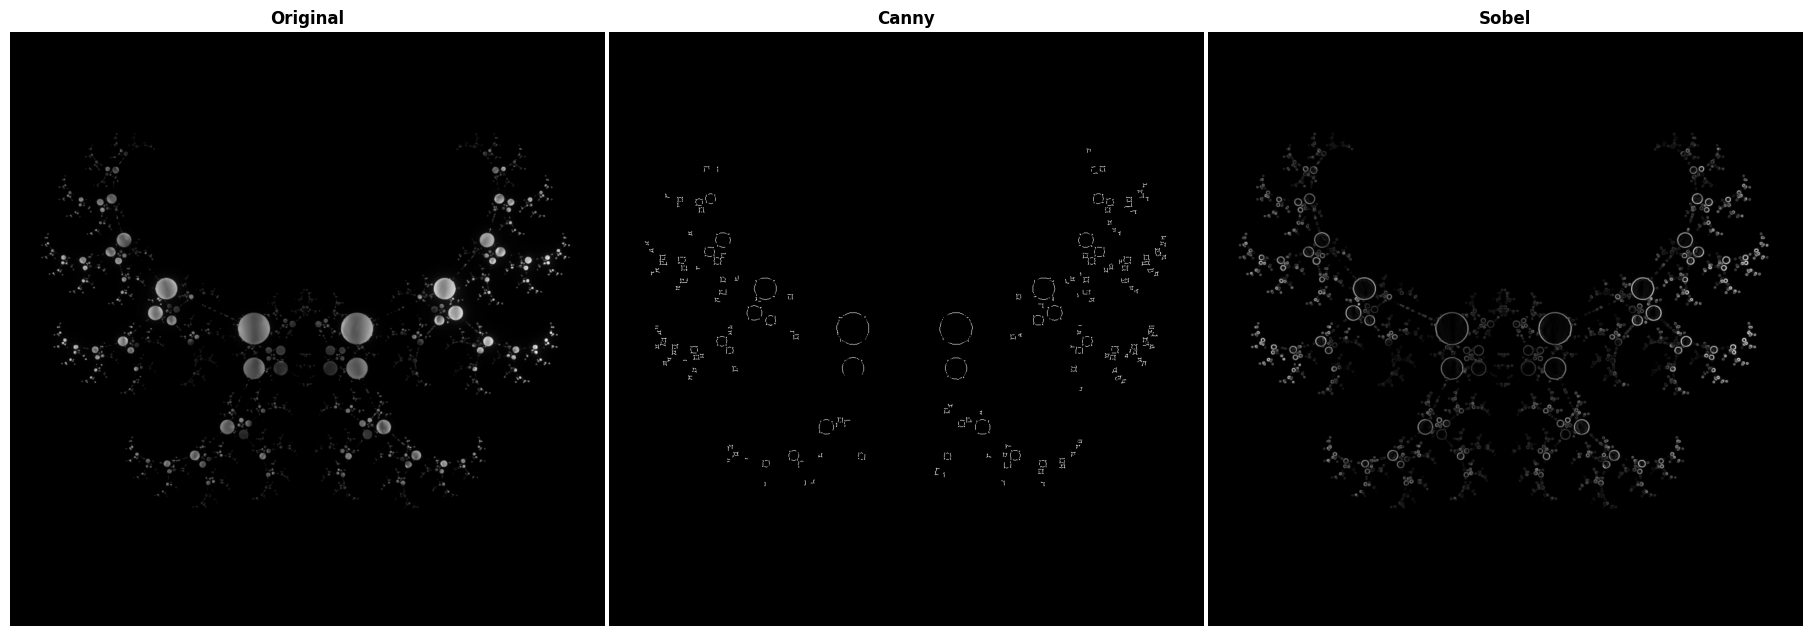

In [14]:
print(f"Combining {len(common)} images...")

for filename in common:
    # Load original image
    original_path = images_dir / filename
    original_img = cv2.imread(str(original_path), cv2.IMREAD_GRAYSCALE)
    
    # Build list of (title, image) tuples
    plot_data: list[tuple[str, any]] = [('Original', original_img)]
    
    for detector in detectors:
        detector_img_path = results_dir / detector / "images" / filename
        detector_img = cv2.imread(str(detector_img_path), cv2.IMREAD_GRAYSCALE)
        plot_data.append((detector.capitalize(), detector_img))
    
    # Create matplotlib figure
    num_subplots = len(plot_data)
    fig, axes = plt.subplots(1, num_subplots, figsize=(6 * num_subplots, 6))
    
    if num_subplots == 1:
        axes = [axes]
    
    # Plot each image
    plot_index: int = 0
    for ax, (title, img) in zip(axes, plot_data):
        ax.imshow(img, cmap='gray')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
        plot_index += 1
    
    plt.tight_layout(pad=0.2)
    plt.show()